In [4]:
# load libraries

import pandas as pd
import sweetviz as sv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
df_irrigation_train = pd.read_csv('playground-series-s6e4/train.csv')
df_irrigation_test = pd.read_csv('playground-series-s6e4/test.csv')

In [ ]:
# Generate the Sweetviz report
report = sv.analyze(df_irrigation_train)
report.show_html('sweetviz_report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [2]:
df_irrigation_test = pd.read_csv('playground-series-s6e4/test.csv')

# generate the sweetviz report for the test dataset
report_test = sv.analyze(df_irrigation_test)
report_test.show_html('sweetviz_report_test.html')

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report_test.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [6]:
# Initial EDA Steps

print(f"Training data shape: {df_irrigation_train.shape}")
display(df_irrigation_train.head())


Training data shape: (630000, 21)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [7]:
# Check for missing values and data types
print("\n--- Data Info ---")
df_irrigation_train.info()


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null

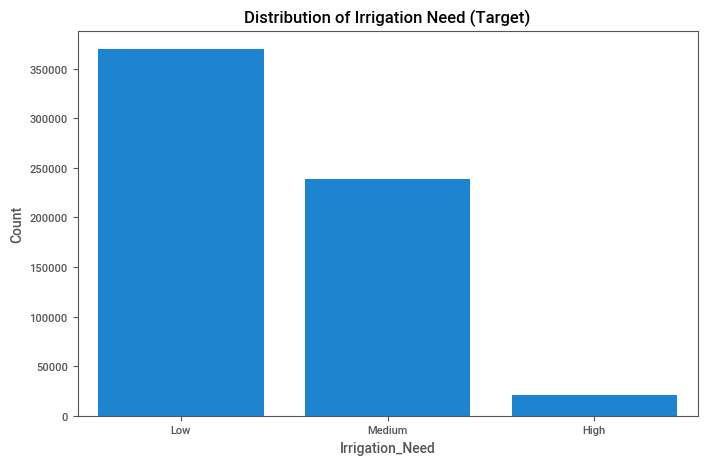

Target Class Percentages:
Irrigation_Need
Low       58.716984
Medium    37.948254
High       3.334762
Name: proportion, dtype: float64


In [10]:
# Analyze the Target Variable (Class Imbalance)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_irrigation_train, x='Irrigation_Need')
plt.title('Distribution of Irrigation Need (Target)')
plt.ylabel('Count')
plt.show()

# Calculate exact percentages
print("Target Class Percentages:")
print(df_irrigation_train['Irrigation_Need'].value_counts(normalize=True) * 100)

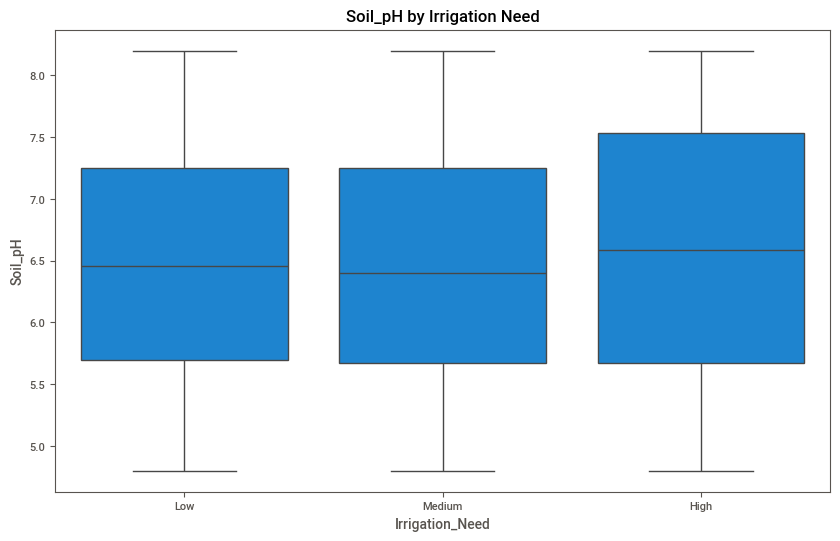

In [11]:
# Numerical Features vs Target
# Let's look at how a feature like Soil Moisture changes by Irrigation need
# (Replace 'Soil_Moisture' with the actual exact column name from the dataset)
numeric_cols = df_irrigation_train.select_dtypes(include=['float64', 'int64']).columns.drop('id', errors='ignore')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_irrigation_train, x='Irrigation_Need', y=numeric_cols[0]) # Example with first numeric column
plt.title(f'{numeric_cols[0]} by Irrigation Need')
plt.show()

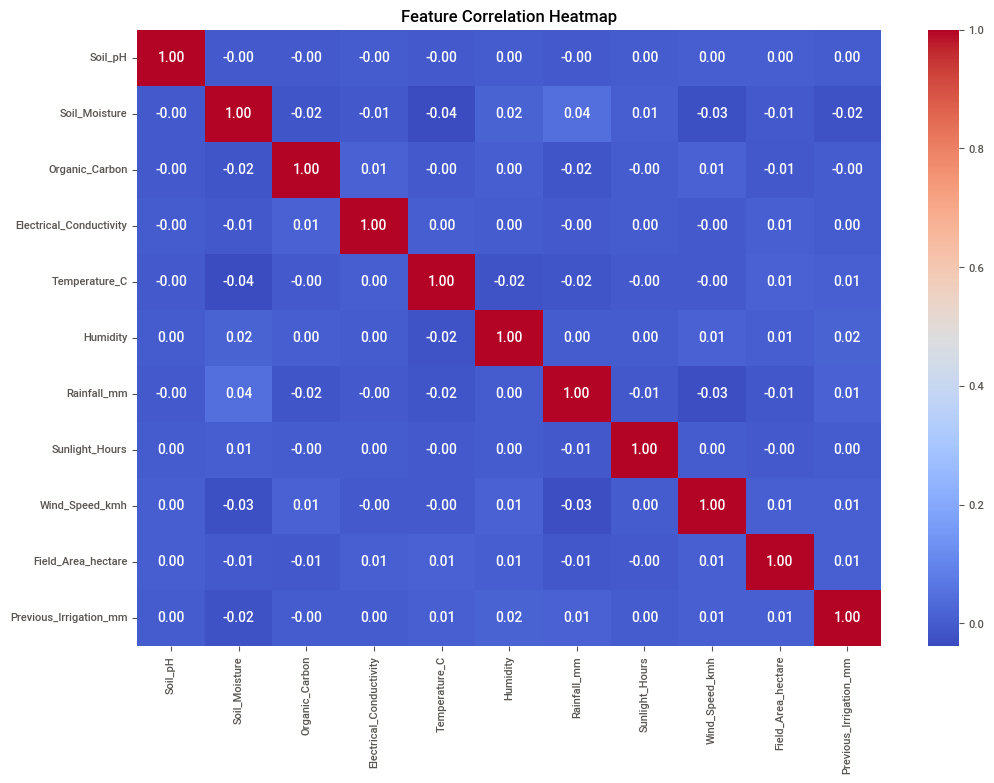

In [12]:
# Correlation Heatmap (Numerical features only)
plt.figure(figsize=(12, 8))
correlation_matrix = df_irrigation_train[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

What insights did I gain? Is there a feature I think is especially important? Any potential issues? Did you try anything new that I learned from Kaggle or other sources? 

I was surprised at the extreme class imbalance in the target variable (Irrigation_Need). The "High" Class only makes up about 3% of the training data. The "Low" class represents about 58% and "Medium" represents about 38%. I was also surprised by the heatmap. However, it does make sense that lower soil moisture and higher temperatures strongly correlate with an increased need for irrigation.

I believe `Soil_Moisture` and `Temperature_C` are very important numerical features. In addition, I think `Crop_Growth_Stage` and `Mulching_Used` are important categorical features (the growth stage are important for determining a plant's water requirements and mulching affects moisture retention).

Potential issues include the "high" class because of the class imbalance. Also in order to achieve a pretty accurate accuracy score, the model will need to be heavily penalized. I think the model at minimum will need to have class weights and sampling techniques.
